# **Taller Riesgo y Análisis de Fraude Bancario**

**Integrantes**
- 

- Nicoll Quesada
- Valentina Ramirez
- Joel Felipe Alba Acosta

**Librerias**
-

In [14]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
import json
import squarify
from sklearn.impute import KNNImputer

# **1. Importación Base de Datos**

In [2]:
df = pd.read_csv("transacciones_banco.csv")

In [5]:
df.head()

,ID_Transaccion,Fecha,Cliente_ID,Monto_COP,Tipo_Transaccion,Ciudad,Estado,Dias_Cliente,Monto_Historico_Promedio
0,TRX001,2024-01-15,CLI0042,450000.0,Transferencia,Bogotá,Completada,89.0,850000
1,TRX002,2024-01-16,CLI0108,2500000.0,Retiro,Medellín,Completada,156.0,2400000
2,TRX003,2024-02-31,CLI0256,-850000.0,Transferencia,Cali,Rechazada,45.0,1200000
3,TRX004,2024-01-18,CLI0512,1200000.0,Pago,Bogotá,Completada,234.0,1150000
4,TRX005,2024-01-19,NaN,750000.0,Retiro,NaN,Pendiente,NaN,980000


## **2. Análisis General Base de Datos**

## **2.1 Información General**

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_Transaccion            500 non-null    str    
 1   Fecha                     499 non-null    str    
 2   Cliente_ID                357 non-null    str    
 3   Monto_COP                 479 non-null    float64
 4   Tipo_Transaccion          500 non-null    str    
 5   Ciudad                    498 non-null    str    
 6   Estado                    500 non-null    str    
 7   Dias_Cliente              357 non-null    float64
 8   Monto_Historico_Promedio  500 non-null    int64  
dtypes: float64(2), int64(1), str(6)
memory usage: 35.3 KB


## **2.2 Datos Únicos por Columna**

In [ ]:
for c in df.columns:
    print(f"La columna {c} tiene {df[c].nunique()} valores únicos")

La columna ID_Transaccion tiene 500
La columna Fecha tiene 86
La columna Cliente_ID tiene 8
La columna Monto_COP tiene 60
La columna Tipo_Transaccion tiene 3
La columna Ciudad tiene 5
La columna Estado tiene 3
La columna Dias_Cliente tiene 7
La columna Monto_Historico_Promedio tiene 34


## **2.3 Datos Faltantes por Columna**

In [6]:
for c in df.columns:
    print(f"La columna {c} tiene {df[c].isnull().sum()} valores faltantes")

La columna ID_Transaccion tiene 0 valores faltantes
La columna Fecha tiene 1 valores faltantes
La columna Cliente_ID tiene 143 valores faltantes
La columna Monto_COP tiene 21 valores faltantes
La columna Tipo_Transaccion tiene 0 valores faltantes
La columna Ciudad tiene 2 valores faltantes
La columna Estado tiene 0 valores faltantes
La columna Dias_Cliente tiene 143 valores faltantes
La columna Monto_Historico_Promedio tiene 0 valores faltantes


# **3. Análisis Exploratorio (EDA)**

In [42]:
def resumen_estadistico_df(df, columna):
    """
    Calcula estadísticas descriptivas avanzadas para una columna numérica
    de un DataFrame y devuelve un DataFrame con los resultados.

    Parámetros:
        df (pd.DataFrame): DataFrame de entrada
        columna (str): Nombre de la columna numérica

    Retorna:
        pd.DataFrame: DataFrame con las métricas estadísticas
    """
    
    if columna not in df.columns:
        raise ValueError(f"La columna '{columna}' no existe en el DataFrame.")
    
    if not np.issubdtype(df[columna].dtype, np.number):
        raise TypeError(f"La columna '{columna}' no es numérica.")
    
    serie = df[columna].dropna()
    
    media = serie.mean()
    std = serie.std()
    
    resultados = {
        "media": media,
        "mediana": serie.median(),
        "q1": serie.quantile(0.25),
        "q3": serie.quantile(0.75),
        "min": serie.min(),
        "max": serie.max(),
        "rango": serie.max() - serie.min(),
        "coef_variacion": std / media if media != 0 else np.nan,
        "varianza": serie.var(),
        "std": std,
        "asimetria": serie.skew(),
        "curtosis": serie.kurt()
    }
    
    # Convertir el diccionario a DataFrame (una fila)
    df_resultado = pd.DataFrame(resultados, index=[columna])
    
    return df_resultado

def plot_numeric_data(column):

    palette = sns.color_palette("Set2", 3)
    colors = np.random.choice(range(len(palette)), 3, replace=False)

    fig, ax = plt.subplots(1, 3, figsize=(14,4))

    fig.suptitle(f"Análisis Gráfico {column}", fontsize=12, fontweight="bold")

    sns.histplot(df[column], kde=False, ax=ax[0], color=palette[colors[0]])
    ax[0].set_title(f"Histograma de {column}")
    ax[0].set_xlabel(column)
    ax[0].set_ylabel("Frecuencia")

    sns.boxplot(x=df[column], ax=ax[1], color=palette[colors[1]])
    ax[1].set_title(f"Boxplot de {column}")
    ax[1].set_xlabel(column)
    ax[1].set_ylabel("")

    sns.kdeplot(x=df[column], ax=ax[2], color=palette[colors[2]], linewidth=2)
    ax[2].set_title(f"Densidad (KDE) de {column}")
    ax[2].set_xlabel(column)
    ax[2].set_ylabel("Densidad")

    plt.tight_layout()
    plt.show()

def resumen_estadistico_categorico(df, columna):

    import pandas as pd
    
    # Frecuencia absoluta
    freq = df[columna].value_counts(dropna=False)
    
    # Frecuencia relativa (%)
    porcentaje = df[columna].value_counts(normalize=True, dropna=False) * 100
    
    # Crear DataFrame
    resumen = pd.DataFrame({
        'Frecuencia': freq,
        'Porcentaje (%)': porcentaje.round(2)
    })
    
    # Moda
    moda = df[columna].mode()
    
    # Agregar moda como columna (repetida para visualización)
    resumen['Moda'] = moda.iloc[0] if not moda.empty else None
    
    return resumen


def plot_categoric_data(df, columna):
    import matplotlib.pyplot as plt
    
    # Conteo ordenado
    conteo = df[columna].value_counts().sort_values(ascending=False)
    
    plt.figure(figsize=(10,6))
    colors = plt.cm.Set1(range(len(conteo)))
    bars = plt.bar(
        conteo.index.astype(str), 
        conteo.values,
        edgecolor='black',
        color=colors
    )
    
    # Título y etiquetas
    plt.title(f"Análisis Gráfico Columna {columna}", fontweight='bold')
    plt.xlabel("Categoria")
    plt.ylabel("Cantidad")
    
    # Valores encima de las barras
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## **3.1 Monto COP**

### **3.1.1 Valores Únicos**

In [44]:
df['Monto_COP'].unique()

array([ 4.50e+05,  2.50e+06, -8.50e+05,  1.20e+06,  7.50e+05,  1.25e+08,
        8.90e+05,  0.00e+00,  3.40e+06,  6.50e+05,  2.10e+06,  1.80e+06,
        9.50e+05,  2.30e+06,  1.90e+06,  4.50e+07,  1.50e+06,  2.20e+06,
        2.80e+06,       nan,  1.25e+06,  1.10e+06,  2.05e+06,  8.50e+05,
        1.45e+06,  7.80e+05,  1.95e+06,  1.70e+06,  3.20e+06,  1.05e+06,
        2.65e+06,  5.50e+05,  2.40e+06,  1.85e+06,  2.90e+06,  3.10e+06,
        7.20e+05,  2.60e+06,  9.80e+05,  6.20e+05,  1.40e+06,  2.95e+06,
        3.50e+06,  1.60e+06,  7.40e+05,  2.70e+06,  9.20e+05,  1.75e+06,
        2.35e+06,  8.20e+05,  1.00e+06,  6.00e+05,  3.30e+06,  1.35e+06,
        7.00e+05,  8.80e+05,  2.00e+06,  3.00e+06,  9.00e+05,  1.15e+06,
        1.65e+06])

### **3.1.2 Análisis Descriptivo**

In [ ]:
import pandas as pd

columns = ['Monto_COP','Dias_Cliente','Monto_Historico_Promedio']

dfs = []

for c in columns:
    temp_df = resumen_estadistico_df(df, c)
    temp_df['Variable'] = c  # para identificar de qué columna viene
    dfs.append(temp_df)

resultado_final = pd.concat(dfs, axis=0, ignore_index=True)
resultado_final

,media,mediana,q1,q3,min,max,rango,coef_variacion,varianza,std,asimetria,curtosis,Variable
0,2.105971e+06,1800000.0,1100000.0,2300000.0,-850000.0,125000000.0,125850000.0,2.851852,3.607105e+13,6.005918e+06,18.761490,373.882789,Monto_COP
1,1.821261e+02,156.0,45.0,234.0,12.0,567.0,555.0,0.948757,2.985757e+04,1.727934e+02,1.362516,0.768819,Dias_Cliente
2,1.423140e+06,1200000.0,920000.0,2100000.0,550000.0,3200000.0,2650000.0,0.438860,3.900749e+11,6.245598e+05,0.392335,-1.240937,Monto_Historico_Promedio


### **3.1.3 Visualización Gráfica**

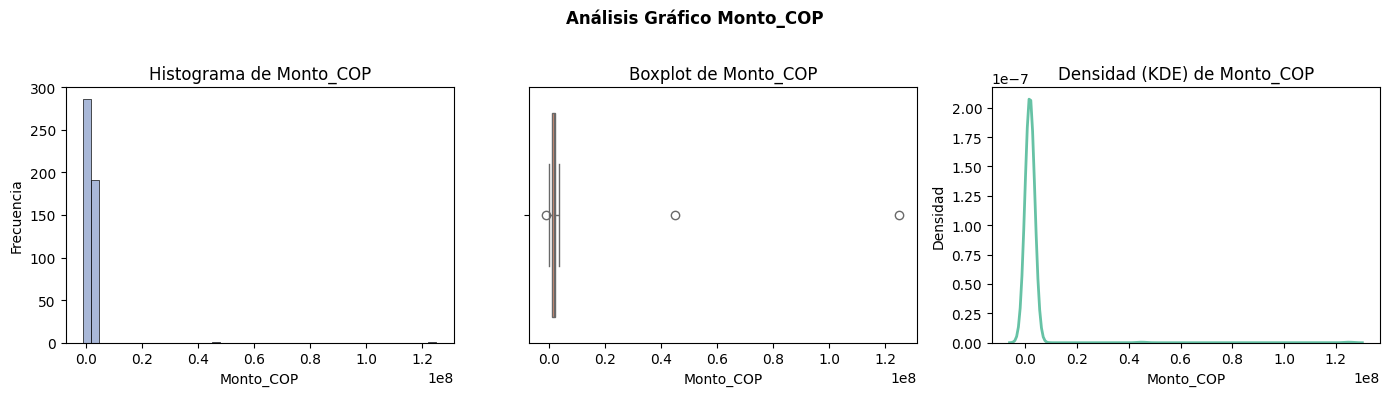

In [16]:
plot_numeric_data('Monto_COP')

## **3.2 Dias Cliente**

### **3.2.1 Valores Únicos**

In [45]:
df['Dias_Cliente'].unique()

array([ 89., 156.,  45., 234.,  nan,  12., 567., 178.])

### **3.2.2 Análisis Descriptivo**

In [18]:
resumen_estadistico_df(df,'Dias_Cliente')

,media,mediana,q1,q3,min,max,rango,coef_variacion,varianza,std,asimetria,curtosis
Dias_Cliente,182.12605,156.0,45.0,234.0,12.0,567.0,555.0,0.948757,29857.571145,172.793435,1.362516,0.768819


### **3.3.3 Visualización Gráfica**

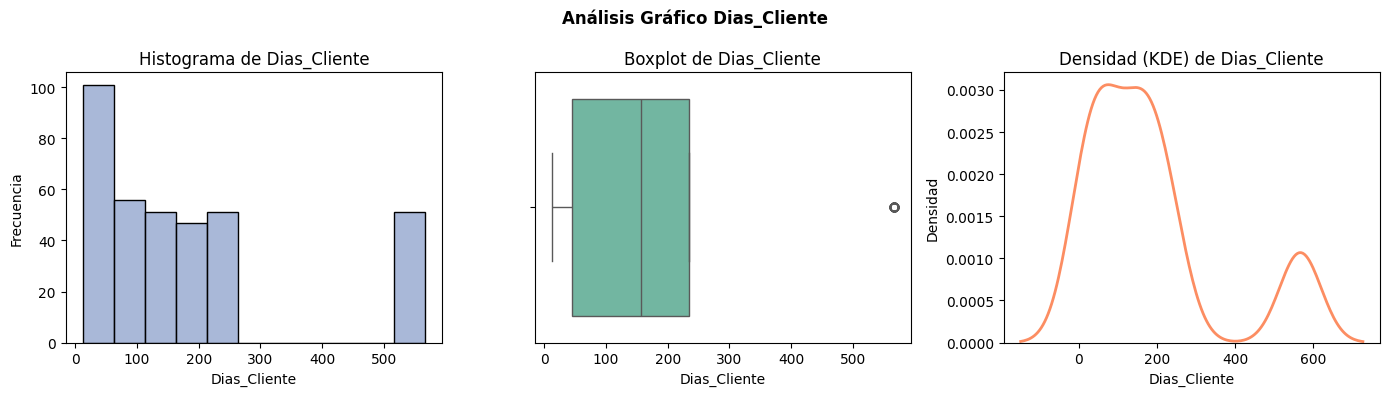

In [25]:
plot_numeric_data('Dias_Cliente')

## **3.3 Monto Historico Acumulado**

### **3.3.1 Valores Únicos**

In [46]:
df['Monto_Historico_Promedio'].unique()

array([ 850000, 2400000, 1200000, 1150000,  980000, 2100000,  920000,
       3200000,  580000, 1400000, 1050000, 2150000,  950000, 2950000,
       2450000, 1850000, 1350000, 2500000, 1100000,  550000, 2650000,
        800000, 1950000, 2350000, 2250000, 1750000, 1900000, 2050000,
       2550000, 1650000,  900000, 1800000, 1300000, 1000000])

### **3.3.2 Análisis Descriptivo**

In [27]:
resumen_estadistico_df(df,"Monto_Historico_Promedio")

,media,mediana,q1,q3,min,max,rango,coef_variacion,varianza,std,asimetria,curtosis
Monto_Historico_Promedio,1423140.0,1200000.0,920000.0,2100000.0,550000,3200000,2650000,0.43886,3.900749e+11,624559.757093,0.392335,-1.240937


### **3.3.3 Análisis Gráfico**

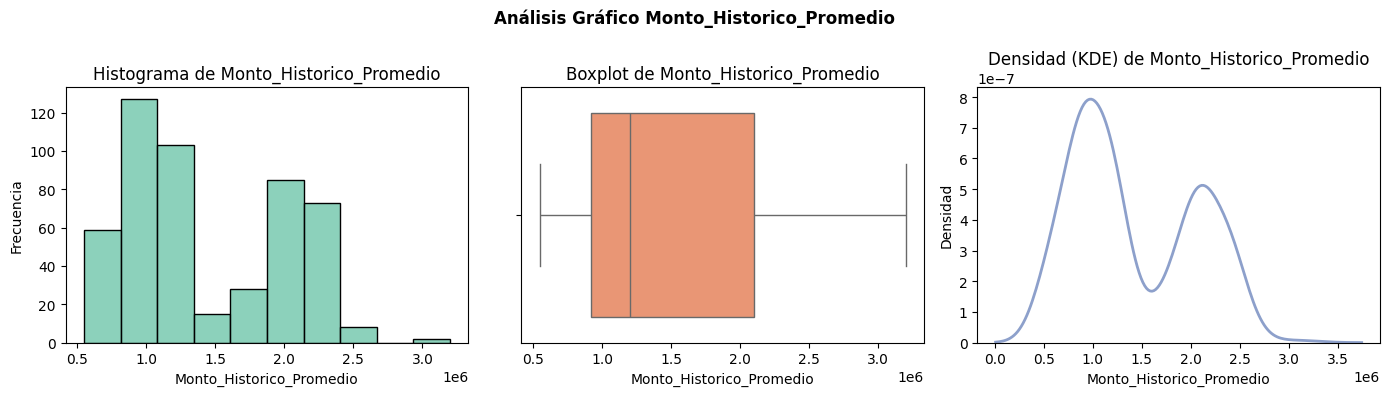

In [37]:
plot_numeric_data('Monto_Historico_Promedio')

## **3.4 Cliente ID**

In [32]:
resumen_estadistico_categorico(df,'Cliente_ID')

,Frecuencia,Porcentaje (%),Moda
Cliente_ID,,,
NaN,143,28.6,CLI0042
CLI0042,56,11.2,CLI0042
CLI0108,51,10.2,CLI0042
CLI0315,51,10.2,CLI0042
CLI0789,51,10.2,CLI0042
CLI0256,50,10.0,CLI0042
CLI0512,50,10.0,CLI0042
CLI0654,47,9.4,CLI0042
CLI0198,1,0.2,CLI0042


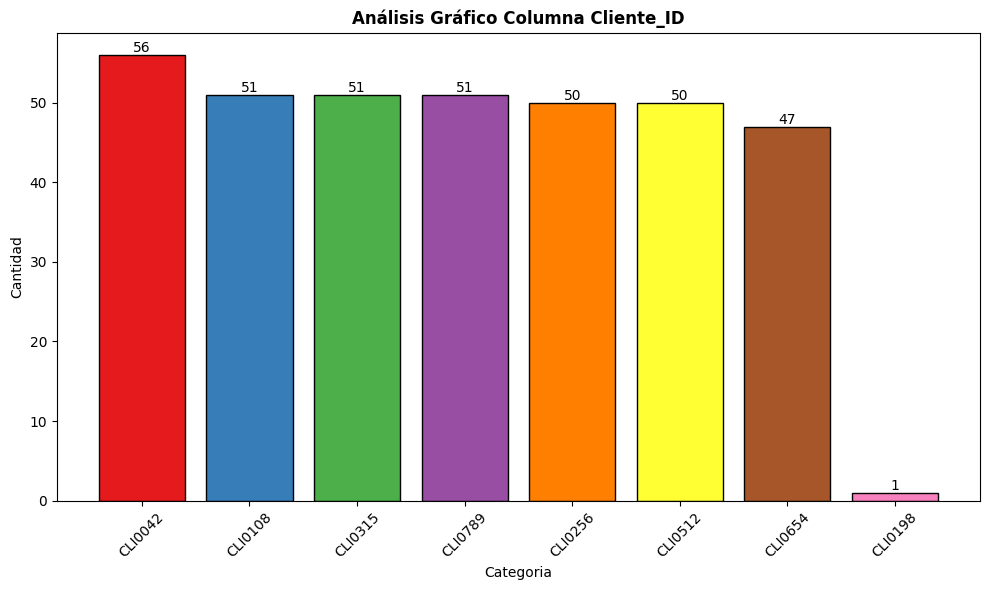

In [43]:
plot_categoric_data(df,'Cliente_ID')

## **3.5 Ciudad**

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_Transaccion            500 non-null    str    
 1   Fecha                     499 non-null    str    
 2   Cliente_ID                357 non-null    str    
 3   Monto_COP                 479 non-null    float64
 4   Tipo_Transaccion          500 non-null    str    
 5   Ciudad                    498 non-null    str    
 6   Estado                    500 non-null    str    
 7   Dias_Cliente              357 non-null    float64
 8   Monto_Historico_Promedio  500 non-null    int64  
dtypes: float64(2), int64(1), str(6)
memory usage: 35.3 KB
